# Equivalent Latitude: Visualisierung im Stil von Añel et al. (2013)

Reproduktion der Abbildungen 1 und 3 aus:  
> Añel JA et al. (2013) *Equivalent Latitude Computation Using Regions of Interest (ROI).*  
> PLoS ONE 8(9): e72970.

**Daten:** ERA5 Potential Vorticity auf der 380 K Isentropenfläche,  
1. Januar 2020, 12 UTC. Interpoliert aus Druckkoordinaten.

**Figure 1 (Añel):** Vergleich der Flächen, die PW (grau) und ROI (rote Kontur)
für einen gegebenen PV-Schwellenwert verwenden.

**Figure 3 (Añel):** PV-Isofläche auf dem Globus, zugehörige äquivalente Breite
als Breitenkreis, zylindrische Projektion.


In [38]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import BoundaryNorm
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import sys
sys.path.insert(0, '..')

from eqlat.piecewise import equivalent_latitude_piecewise
from eqlat.roi_fast import equivalent_latitude_roi

%matplotlib inline
plt.rcParams['figure.dpi'] = 130
plt.rcParams['figure.figsize'] = (12, 6)


In [39]:
# --- Daten laden ---
data = np.load('../data_pv380k.npz')
pv = data['pv']
lat = data['lat']
lon = data['lon']

# Lat von 90→-90 zu -90→90
if lat[0] > lat[-1]:
    lat = lat[::-1]
    pv = pv[::-1, :]

print(f"ERA5 PV auf 380 K, 1. Januar 2020, 12 UTC")
print(f"Gitter: {len(lat)}×{len(lon)} ({lat[1]-lat[0]:.2f}°)")
print(f"PV-Bereich: [{pv.min():.1f}, {pv.max():.1f}] PVU")


ERA5 PV auf 380 K, 1. Januar 2020, 12 UTC
Gitter: 721×1440 (0.25°)
PV-Bereich: [-27.8, 15.5] PVU


In [40]:
# --- Equivalent Latitude berechnen ---
pv_threshold = 2.0  # PVU (dynamische Tropopause)

# Beide Methoden
res_pw = equivalent_latitude_piecewise(pv, lat, lon, pv_thresholds=np.array([pv_threshold]))
res_roi = equivalent_latitude_roi(pv, lat, lon, pv_thresholds=np.array([pv_threshold]))

eqlat_pw = res_pw['eqlat'][0]
eqlat_roi = res_roi['eqlat'][0]

print(f"PV-Schwellenwert: {pv_threshold} PVU")
print(f"Äquivalente Breite (PW):  {eqlat_pw:.2f}°")
print(f"Äquivalente Breite (ROI): {eqlat_roi:.2f}°")
print(f"Differenz: {eqlat_pw - eqlat_roi:.3f}°")


PV-Schwellenwert: 2.0 PVU
Äquivalente Breite (PW):  14.36°
Äquivalente Breite (ROI): 14.40°
Differenz: -0.039°


---
## Figure 1: PW-Fläche vs. ROI-Kontur

Vergleich der beiden Methoden für den 2 PVU Schwellenwert:
- **Grau gefüllt:** Gitterzellen, in denen PV > 2 PVU (Piecewise-Methode zählt diese Fläche)
- **Rote Kontur:** PV = 2 PVU Isolinie (ROI-Methode berechnet die eingeschlossene Fläche)
- **Blauer Kreis:** Äquivalente Breite φ_e (Breitenkreis mit gleicher Fläche)


/opt/miniconda3/envs/earth-analytics-python/lib/python3.11/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


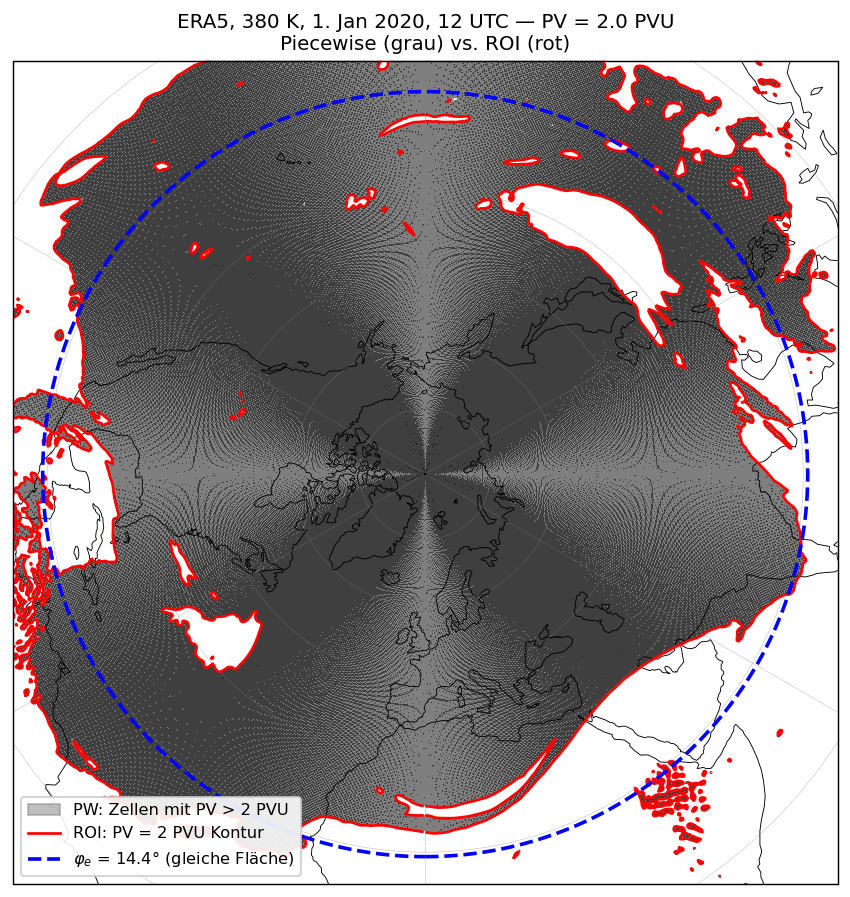

In [41]:
# --- Figure 1: PW area vs ROI contour ---
fig = plt.figure(figsize=(14, 7))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.NorthPolarStereo())

# Limit to NH
ax.set_extent([-180, 180, 10, 90], ccrs.PlateCarree())

# Grid for plotting
lon2d, lat2d = np.meshgrid(lon, lat)

# PW method: shade all grid cells where PV > threshold (gray)
pv_mask = np.ma.masked_where(pv <= pv_threshold, pv)
ax.pcolormesh(lon, lat, pv_mask, transform=ccrs.PlateCarree(),
              cmap='Greys', vmin=pv_threshold, vmax=pv_threshold + 0.01,
              alpha=0.5, shading='auto')

# ROI method: contour at PV = threshold (red)
cs = ax.contour(lon, lat, pv, levels=[pv_threshold],
                transform=ccrs.PlateCarree(),
                colors='red', linewidths=1.5)

# Equivalent latitude circle (blue dashed)
eqlat_circle_lon = np.linspace(0, 360, 361)
eqlat_circle_lat = np.full_like(eqlat_circle_lon, eqlat_pw)
ax.plot(eqlat_circle_lon, eqlat_circle_lat,
        transform=ccrs.PlateCarree(),
        color='blue', linewidth=2, linestyle='--',
        label=f'$\\varphi_e$ = {eqlat_pw:.1f}°')

# Coastlines and gridlines
ax.add_feature(cfeature.COASTLINE, linewidth=0.5, color='k')
ax.gridlines(draw_labels=False, linewidth=0.3, color='gray', alpha=0.5,
             ylocs=np.arange(0, 90, 15))

# Legend
gray_patch = mpatches.Patch(color='gray', alpha=0.5, label='PW: Zellen mit PV > 2 PVU')
red_line = plt.Line2D([0], [0], color='red', lw=1.5, label='ROI: PV = 2 PVU Kontur')
blue_line = plt.Line2D([0], [0], color='blue', lw=2, ls='--',
                       label=f'$\\varphi_e$ = {eqlat_pw:.1f}° (gleiche Fläche)')
ax.legend(handles=[gray_patch, red_line, blue_line],
          loc='lower left', fontsize=9, framealpha=0.9)

ax.set_title(f'ERA5, 380 K, 1. Jan 2020, 12 UTC — PV = {pv_threshold} PVU\n'
             f'Piecewise (grau) vs. ROI (rot)',
             fontsize=11)

plt.tight_layout()
plt.show()


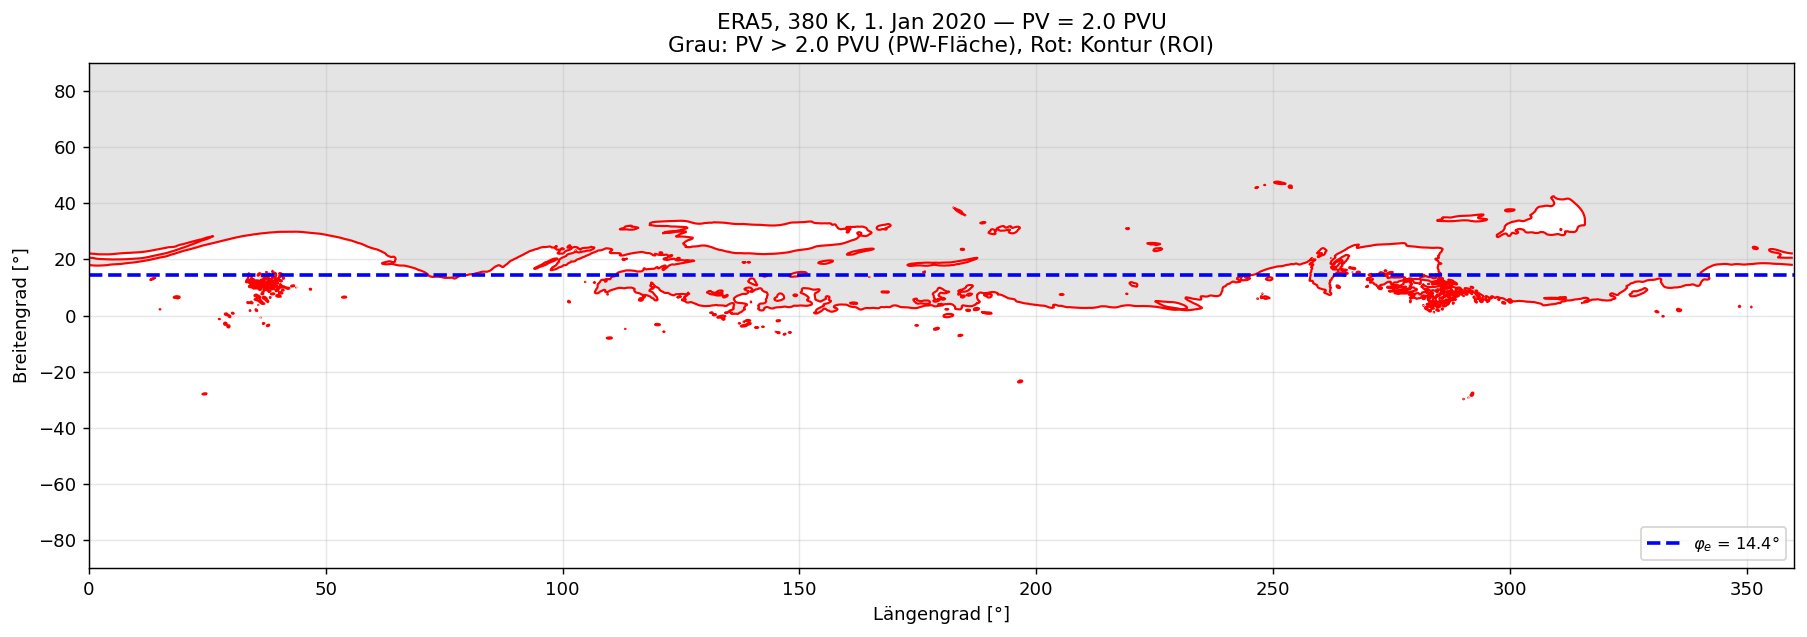

In [42]:
# --- Figure 1b: Zylindrische Projektion (wie Añel Fig. 1 unterer Teil) ---
fig, ax = plt.subplots(figsize=(14, 5))

# Shade PW area
ax.contourf(lon, lat, (pv > pv_threshold).astype(float),
            levels=[0.5, 1.5], colors=['lightgray'], alpha=0.6)

# ROI contour
ax.contour(lon, lat, pv, levels=[pv_threshold],
           colors='red', linewidths=1.2)

# Equivalent latitude line
ax.axhline(eqlat_pw, color='blue', linewidth=2, linestyle='--',
           label=f'$\\varphi_e$ = {eqlat_pw:.1f}°')

ax.set_xlim(0, 360)
ax.set_ylim(-90, 90)
ax.set_xlabel('Längengrad [°]')
ax.set_ylabel('Breitengrad [°]')
ax.set_title(f'ERA5, 380 K, 1. Jan 2020 — PV = {pv_threshold} PVU\n'
             f'Grau: PV > {pv_threshold} PVU (PW-Fläche), Rot: Kontur (ROI)')
ax.legend(loc='lower right', fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


---
## Figure 3: PV-Isofläche und äquivalente Breite

Reproduktion im Stil von Añel et al. Figure 3:
1. **Oben links:** PV-Isofläche auf orthographischer Projektion (Blick auf NH-Pol)
2. **Oben rechts:** Zugehörige φ_e als Breitenkreis auf dem Globus
3. **Unten:** Zylindrische Projektion mit PV-Feld, Kontur und φ_e


φ_e bei 4.0 PVU: 27.5° (PW), 27.5° (ROI)


/opt/miniconda3/envs/earth-analytics-python/lib/python3.11/site-packages/cartopy/mpl/geoaxes.py:841: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  self.set_xlim([x1, x2])


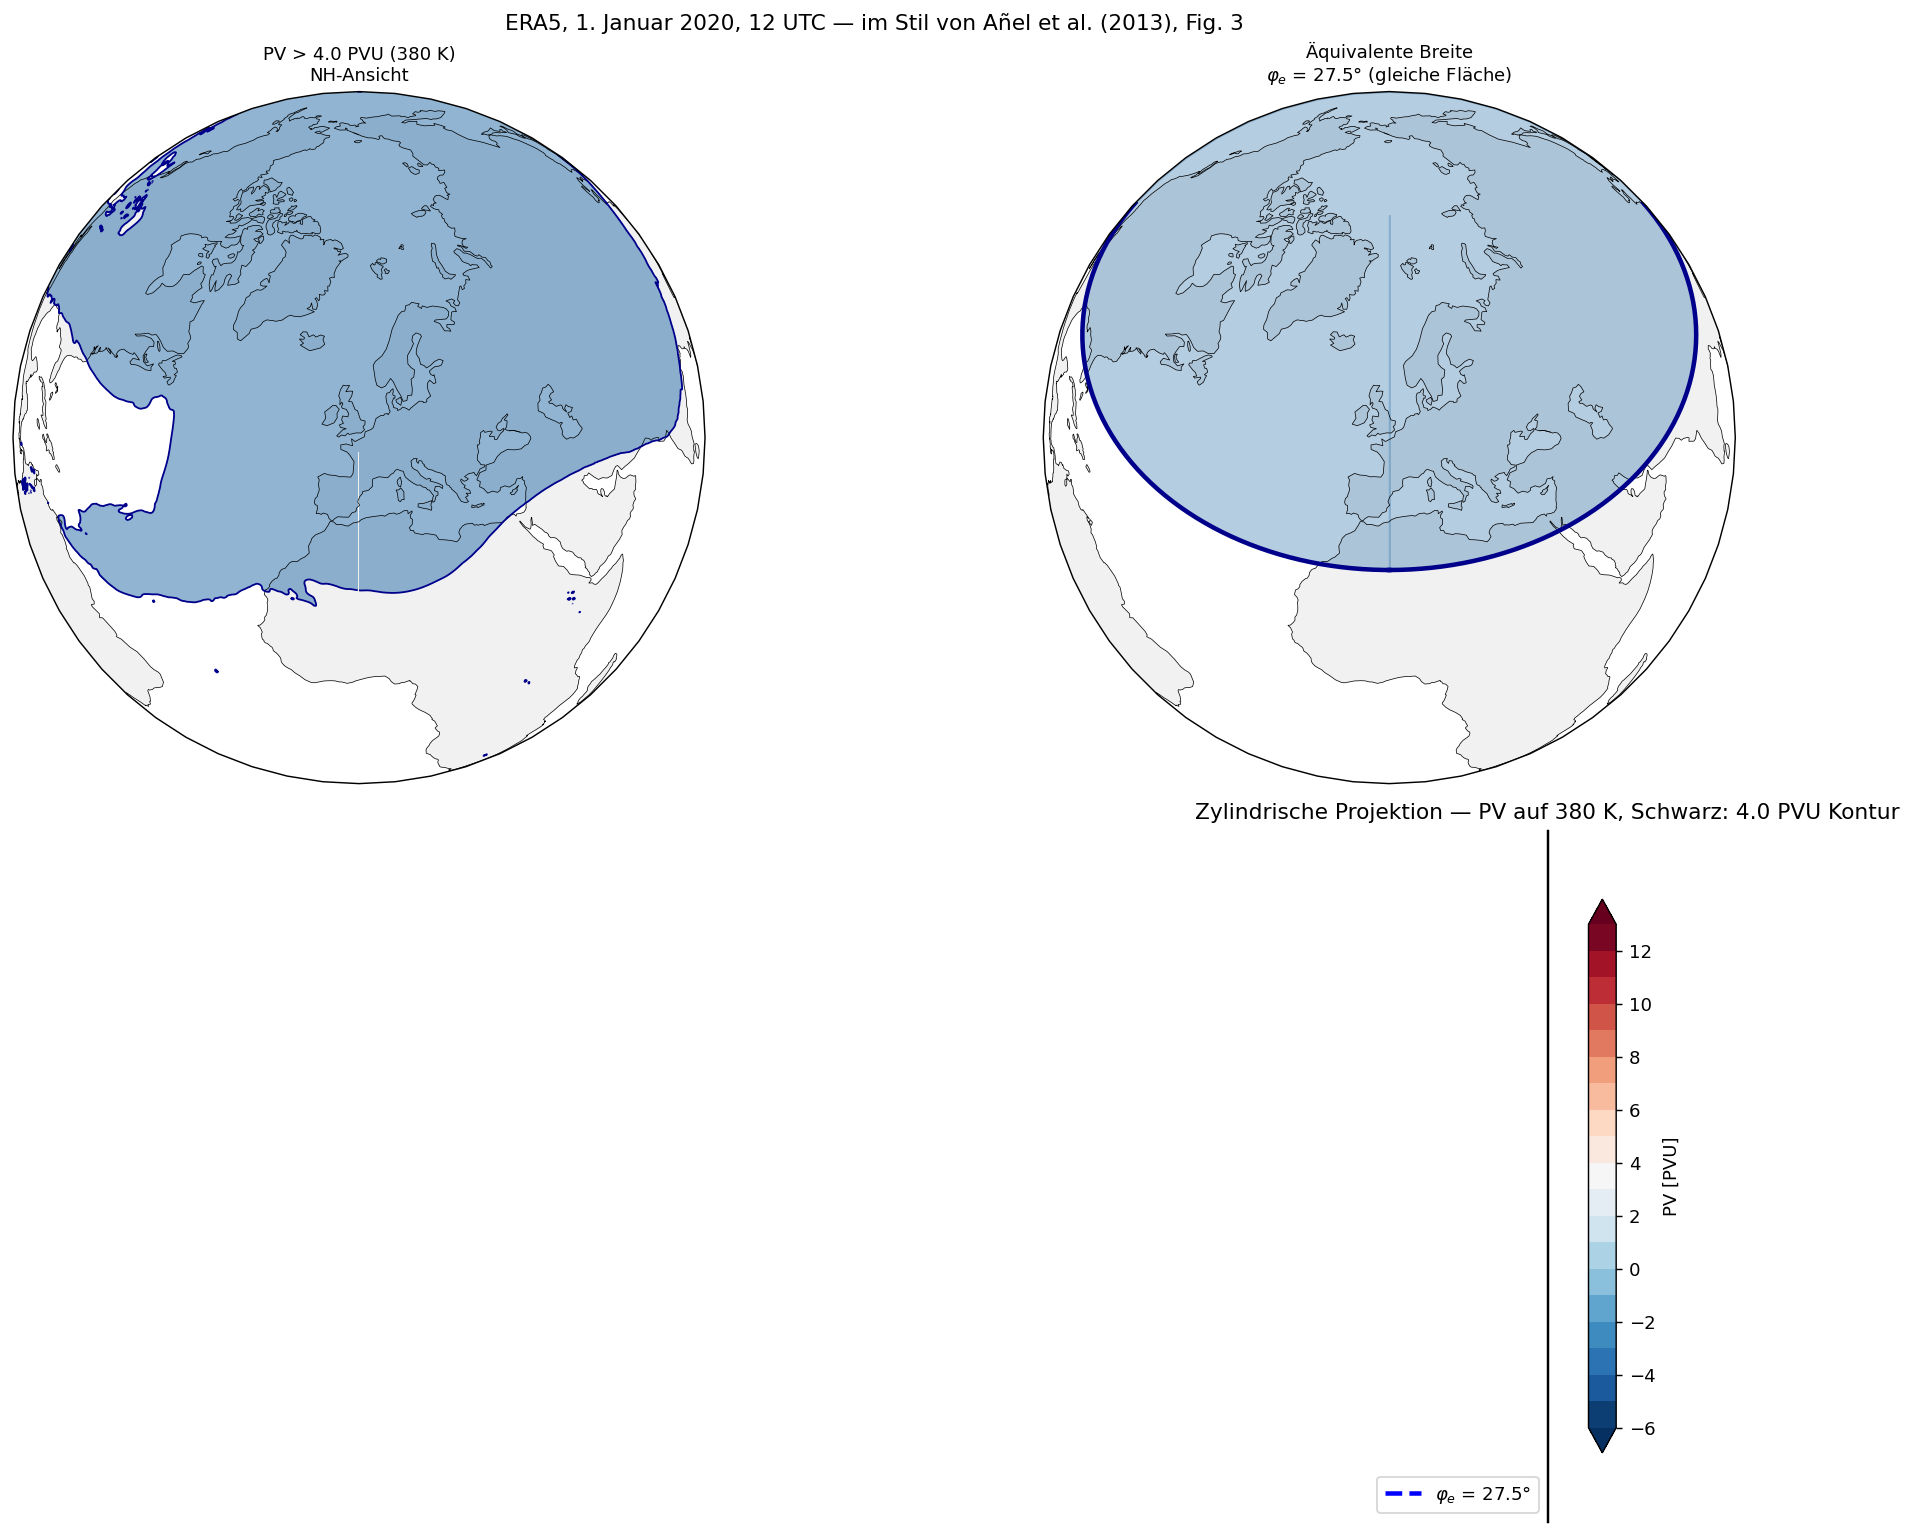

In [43]:
# --- Figure 3: Globus + φ_e + zylindrische Projektion ---
pv_level = 4.0  # PVU (wie in Añel Fig. 3)

# Berechne φ_e für 4 PVU
res_pw_4 = equivalent_latitude_piecewise(pv, lat, lon, pv_thresholds=np.array([pv_level]))
res_roi_4 = equivalent_latitude_roi(pv, lat, lon, pv_thresholds=np.array([pv_level]))
eqlat_4pvu = res_pw_4['eqlat'][0]
print(f"φ_e bei {pv_level} PVU: {eqlat_4pvu:.1f}° (PW), {res_roi_4['eqlat'][0]:.1f}° (ROI)")

fig = plt.figure(figsize=(16, 12))

# --- Panel 1: Orthographic NH (Globus) ---
ax1 = fig.add_subplot(2, 2, 1, projection=ccrs.Orthographic(0, 50))
ax1.add_feature(cfeature.COASTLINE, linewidth=0.4)
ax1.add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.3)

# PV > threshold shaded
ax1.contourf(lon, lat, pv, levels=[pv_level, 50],
             transform=ccrs.PlateCarree(),
             colors=['steelblue'], alpha=0.6)
ax1.contour(lon, lat, pv, levels=[pv_level],
            transform=ccrs.PlateCarree(),
            colors='darkblue', linewidths=1.0)

ax1.set_title(f'PV > {pv_level} PVU (380 K)\nNH-Ansicht', fontsize=10)
ax1.set_global()

# --- Panel 2: Globus mit φ_e Kreis ---
ax2 = fig.add_subplot(2, 2, 2, projection=ccrs.Orthographic(0, 50))
ax2.add_feature(cfeature.COASTLINE, linewidth=0.4)
ax2.add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.3)

# φ_e circle (filled polar cap)
theta_fill = np.linspace(0, 360, 361)
# Fill from φ_e to pole
ax2.fill_between(theta_fill, eqlat_4pvu, 90,
                 transform=ccrs.PlateCarree(),
                 color='steelblue', alpha=0.4)
ax2.plot(theta_fill, np.full_like(theta_fill, eqlat_4pvu),
         transform=ccrs.PlateCarree(),
         color='darkblue', linewidth=2.5)

ax2.set_title(f'Äquivalente Breite\n$\\varphi_e$ = {eqlat_4pvu:.1f}° (gleiche Fläche)', fontsize=10)
ax2.set_global()

# --- Panel 3: Zylindrische Projektion ---
ax3 = fig.add_subplot(2, 1, 2, projection=ccrs.PlateCarree())
ax3.set_extent([0, 360, -90, 90], ccrs.PlateCarree())
ax3.add_feature(cfeature.COASTLINE, linewidth=0.3)

# PV field
levels_pv = np.arange(-6, 14, 1)
c = ax3.contourf(lon, lat, pv, levels=levels_pv, cmap='RdBu_r',
                 transform=ccrs.PlateCarree(), extend='both')
plt.colorbar(c, ax=ax3, label='PV [PVU]', shrink=0.8, pad=0.02)

# PV contour at threshold
ax3.contour(lon, lat, pv, levels=[pv_level],
            transform=ccrs.PlateCarree(),
            colors='k', linewidths=1.5)

# φ_e line
ax3.plot([0, 360], [eqlat_4pvu, eqlat_4pvu],
         transform=ccrs.PlateCarree(),
         color='blue', linewidth=2.5, linestyle='--',
         label=f'$\\varphi_e$ = {eqlat_4pvu:.1f}°')

ax3.set_xlabel('Längengrad [°]')
ax3.set_ylabel('Breitengrad [°]')
ax3.set_title(f'Zylindrische Projektion — PV auf 380 K, Schwarz: {pv_level} PVU Kontur')
ax3.legend(loc='lower right', fontsize=10)

plt.suptitle('ERA5, 1. Januar 2020, 12 UTC — im Stil von Añel et al. (2013), Fig. 3',
             fontsize=12, y=0.98)
plt.tight_layout()
plt.show()


---
## Ergänzung: Mehrere PV-Schwellenwerte

Vergleich für verschiedene PV-Werte (2, 4, 6, 8 PVU) — zeigt wie sich
die äquivalente Breite mit dem Schwellenwert polwärts verschiebt.


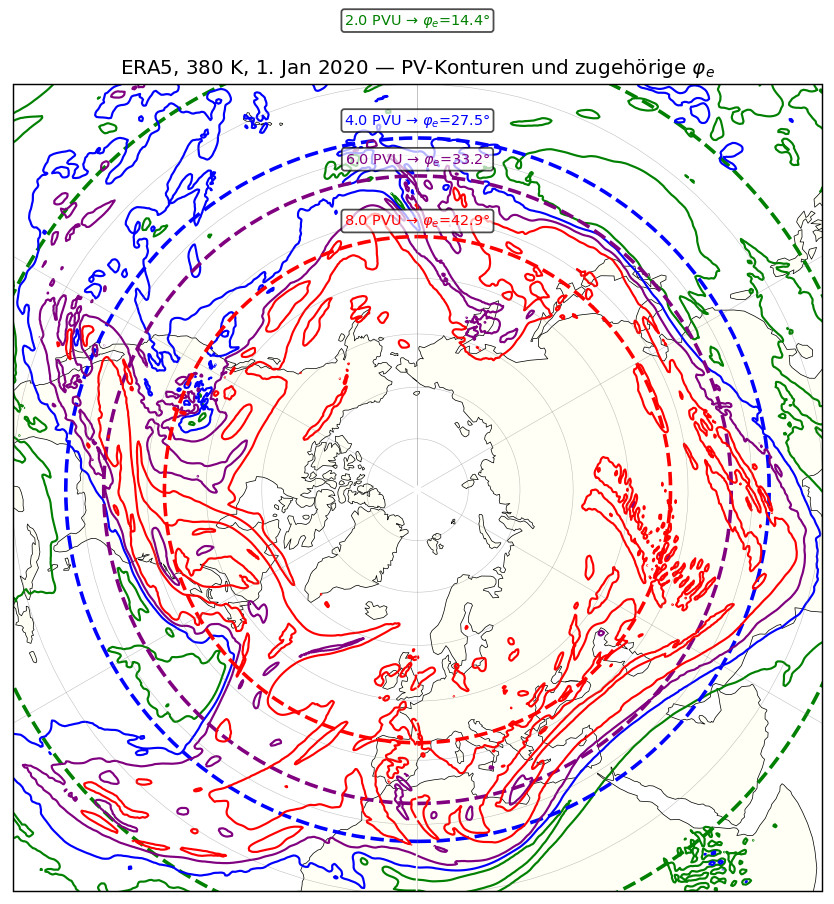

In [44]:
# --- Mehrere Schwellenwerte auf einer Karte ---
pv_levels_multi = [2.0, 4.0, 6.0, 8.0]
colors_multi = ['green', 'blue', 'purple', 'red']

# Berechne φ_e für alle
res_multi = equivalent_latitude_piecewise(pv, lat, lon, pv_thresholds=np.array(pv_levels_multi))

fig = plt.figure(figsize=(14, 7))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.NorthPolarStereo())
ax.set_extent([-180, 180, 20, 90], ccrs.PlateCarree())
ax.add_feature(cfeature.COASTLINE, linewidth=0.4)
ax.add_feature(cfeature.LAND, facecolor='lightyellow', alpha=0.3)

circle_lon = np.linspace(0, 360, 361)

for pv_lev, col, eqlat_val in zip(pv_levels_multi, colors_multi, res_multi['eqlat']):
    # PV contour
    ax.contour(lon, lat, pv, levels=[pv_lev],
               transform=ccrs.PlateCarree(),
               colors=col, linewidths=1.2)
    # φ_e circle
    ax.plot(circle_lon, np.full_like(circle_lon, eqlat_val),
            transform=ccrs.PlateCarree(),
            color=col, linewidth=2, linestyle='--')
    ax.text(180, eqlat_val - 2, f'{pv_lev} PVU → $\\varphi_e$={eqlat_val:.1f}°',
            transform=ccrs.PlateCarree(),
            fontsize=8, color=col, ha='center',
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7))

ax.gridlines(draw_labels=False, linewidth=0.3, color='gray', alpha=0.5,
             ylocs=np.arange(20, 90, 10))
ax.set_title('ERA5, 380 K, 1. Jan 2020 — PV-Konturen und zugehörige $\\varphi_e$',
             fontsize=11)

plt.tight_layout()
plt.show()


---
## Auflösungsvergleich: 0.25° vs. 1.0° vs. 2.5°

Añel et al. (2013) verwenden NCEP/NCAR Reanalysis bei 2.5° × 2.5°.
Durch Block-Mittelung der ERA5-Daten simulieren wir verschiedene Auflösungen
und zeigen, wie der Unterschied zwischen PW und ROI mit dem Gitter wächst.


In [45]:
# --- Coarsening: ERA5 auf verschiedene Auflösungen mitteln ---

def coarsen_grid(pv, lat, lon, factor):
    """Block-Mittelung auf gröberes Gitter."""
    nlat_new = len(lat) // factor
    nlon_new = len(lon) // factor
    pv_trim = pv[:nlat_new*factor, :nlon_new*factor]
    pv_coarse = pv_trim.reshape(nlat_new, factor, nlon_new, factor).mean(axis=(1, 3))
    lat_coarse = lat[:nlat_new*factor].reshape(nlat_new, factor).mean(axis=1)
    lon_coarse = lon[:nlon_new*factor].reshape(nlon_new, factor).mean(axis=1)
    return pv_coarse, lat_coarse, lon_coarse

# Drei Auflösungen
grids = [
    (1,  '0.25°'),
    (4,  '1.0°'),
    (10, '2.5°'),
]

thresh_compare = np.linspace(-5, 12, 80)
results_grid = {}

for factor, label in grids:
    if factor == 1:
        pv_c, lat_c, lon_c = pv, lat, lon
    else:
        pv_c, lat_c, lon_c = coarsen_grid(pv, lat, lon, factor)
    
    res_pw = equivalent_latitude_piecewise(pv_c, lat_c, lon_c,
                                          pv_thresholds=thresh_compare)
    res_roi = equivalent_latitude_roi(pv_c, lat_c, lon_c,
                                     pv_thresholds=thresh_compare)
    
    diff = res_pw['eqlat'] - res_roi['eqlat']
    results_grid[label] = {
        'pw': res_pw['eqlat'],
        'roi': res_roi['eqlat'],
        'diff': diff,
        'pv_c': pv_c, 'lat_c': lat_c, 'lon_c': lon_c
    }
    print(f"{label:>5}: {len(lat_c)}×{len(lon_c)} Punkte, "
          f"max|PW−ROI| = {np.max(np.abs(diff)):.3f}°, "
          f"mean|PW−ROI| = {np.mean(np.abs(diff)):.3f}°")


0.25°: 721×1440 Punkte, max|PW−ROI| = 0.059°, mean|PW−ROI| = 0.029°
 1.0°: 180×360 Punkte, max|PW−ROI| = 0.311°, mean|PW−ROI| = 0.114°
 2.5°: 72×144 Punkte, max|PW−ROI| = 0.714°, mean|PW−ROI| = 0.273°


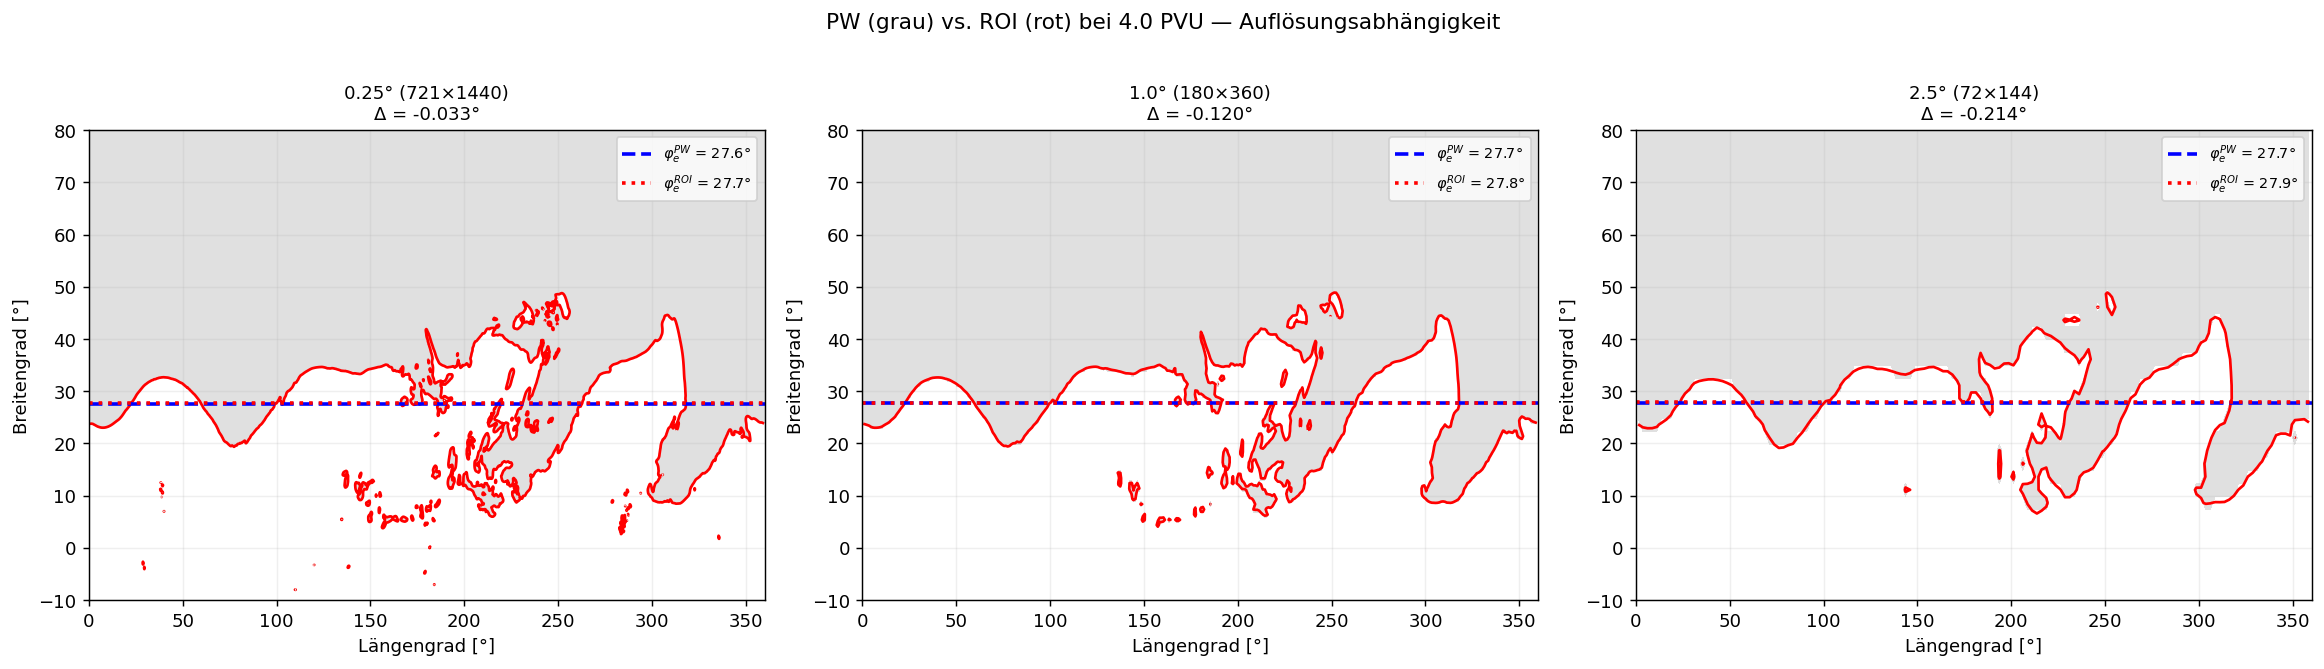

In [46]:
# --- Figure 1 bei verschiedenen Auflösungen (3 Panels) ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

pv_lev_compare = 4.0  # PVU

for ax, (factor, label) in zip(axes, grids):
    r = results_grid[label]
    pv_c = r['pv_c']
    lat_c = r['lat_c']
    lon_c = r['lon_c']
    
    # φ_e at this threshold
    idx = np.argmin(np.abs(thresh_compare - pv_lev_compare))
    eqlat_pw_c = r['pw'][idx]
    eqlat_roi_c = r['roi'][idx]
    
    # PW area (gray)
    ax.contourf(lon_c, lat_c, (pv_c > pv_lev_compare).astype(float),
                levels=[0.5, 1.5], colors=['lightgray'], alpha=0.7)
    
    # ROI contour (red)
    ax.contour(lon_c, lat_c, pv_c, levels=[pv_lev_compare],
               colors='red', linewidths=1.5)
    
    # φ_e lines
    ax.axhline(eqlat_pw_c, color='blue', lw=2, ls='--',
               label=f'$\\varphi_e^{{PW}}$ = {eqlat_pw_c:.1f}°')
    ax.axhline(eqlat_roi_c, color='red', lw=2, ls=':',
               label=f'$\\varphi_e^{{ROI}}$ = {eqlat_roi_c:.1f}°')
    
    ax.set_xlim(0, 360)
    ax.set_ylim(-10, 80)
    ax.set_xlabel('Längengrad [°]')
    ax.set_ylabel('Breitengrad [°]')
    ax.set_title(f'{label} ({len(lat_c)}×{len(lon_c)})\n'
                 f'Δ = {eqlat_pw_c - eqlat_roi_c:.3f}°', fontsize=10)
    ax.legend(fontsize=8, loc='upper right')
    ax.grid(True, alpha=0.2)

fig.suptitle(f'PW (grau) vs. ROI (rot) bei {pv_lev_compare} PVU — Auflösungsabhängigkeit',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()


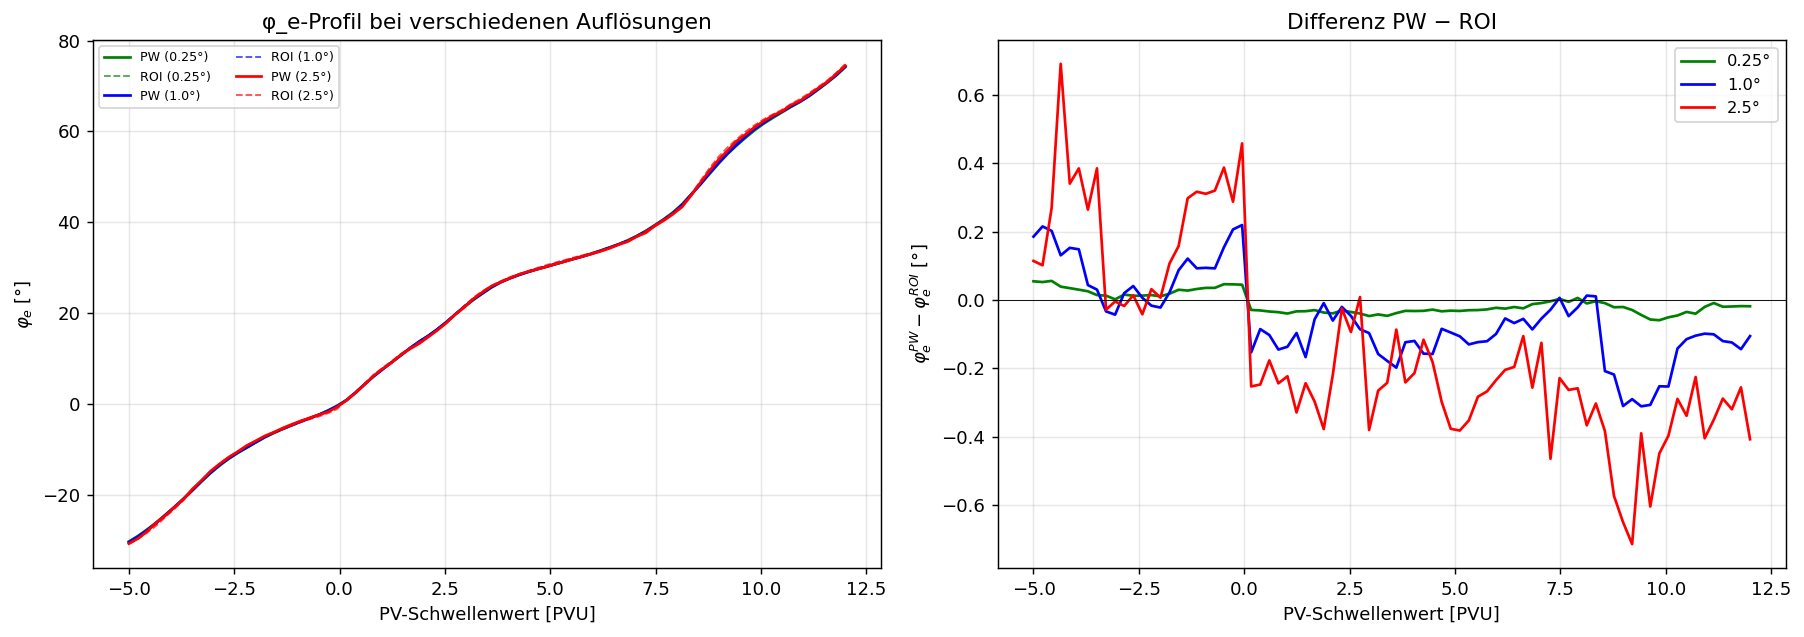


Auflösung   max|PW−ROI|  mean|PW−ROI|    @2PVU    @4PVU
0.25°            0.059°        0.029°  -0.039°  -0.033°
1.0°             0.311°        0.114°  -0.061°  -0.120°
2.5°             0.714°        0.273°  -0.219°  -0.214°


In [47]:
# --- Differenz PW−ROI für alle Auflösungen ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors_res = ['green', 'blue', 'red']

# Panel 1: φ_e profiles
ax = axes[0]
for (_, label), col in zip(grids, colors_res):
    r = results_grid[label]
    ax.plot(thresh_compare, r['pw'], '-', color=col, lw=1.5,
            label=f'PW ({label})')
    ax.plot(thresh_compare, r['roi'], '--', color=col, lw=1.0,
            label=f'ROI ({label})', alpha=0.7)

ax.set_xlabel('PV-Schwellenwert [PVU]')
ax.set_ylabel('$\\varphi_e$ [°]')
ax.set_title('φ_e-Profil bei verschiedenen Auflösungen')
ax.legend(fontsize=7, ncol=2)
ax.grid(True, alpha=0.3)

# Panel 2: Differenz PW−ROI
ax = axes[1]
for (_, label), col in zip(grids, colors_res):
    r = results_grid[label]
    ax.plot(thresh_compare, r['diff'], '-', color=col, lw=1.5, label=label)

ax.axhline(0, color='k', lw=0.5)
ax.set_xlabel('PV-Schwellenwert [PVU]')
ax.set_ylabel('$\\varphi_e^{PW} - \\varphi_e^{ROI}$ [°]')
ax.set_title('Differenz PW − ROI')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Summary table
print(f"\n{'Auflösung':<10} {'max|PW−ROI|':>12} {'mean|PW−ROI|':>13} {'@2PVU':>8} {'@4PVU':>8}")
print('=' * 55)
for (_, label) in grids:
    r = results_grid[label]
    idx2 = np.argmin(np.abs(thresh_compare - 2.0))
    idx4 = np.argmin(np.abs(thresh_compare - 4.0))
    print(f"{label:<10} {np.max(np.abs(r['diff'])):>11.3f}° {np.mean(np.abs(r['diff'])):>12.3f}° "
          f"{r['diff'][idx2]:>7.3f}° {r['diff'][idx4]:>7.3f}°")


---
## PW vs. ROI: Volles φ_e-Profil

Vergleich der beiden Methoden über den gesamten PV-Bereich.
Bei 0.25°-Auflösung sind die Unterschiede minimal.


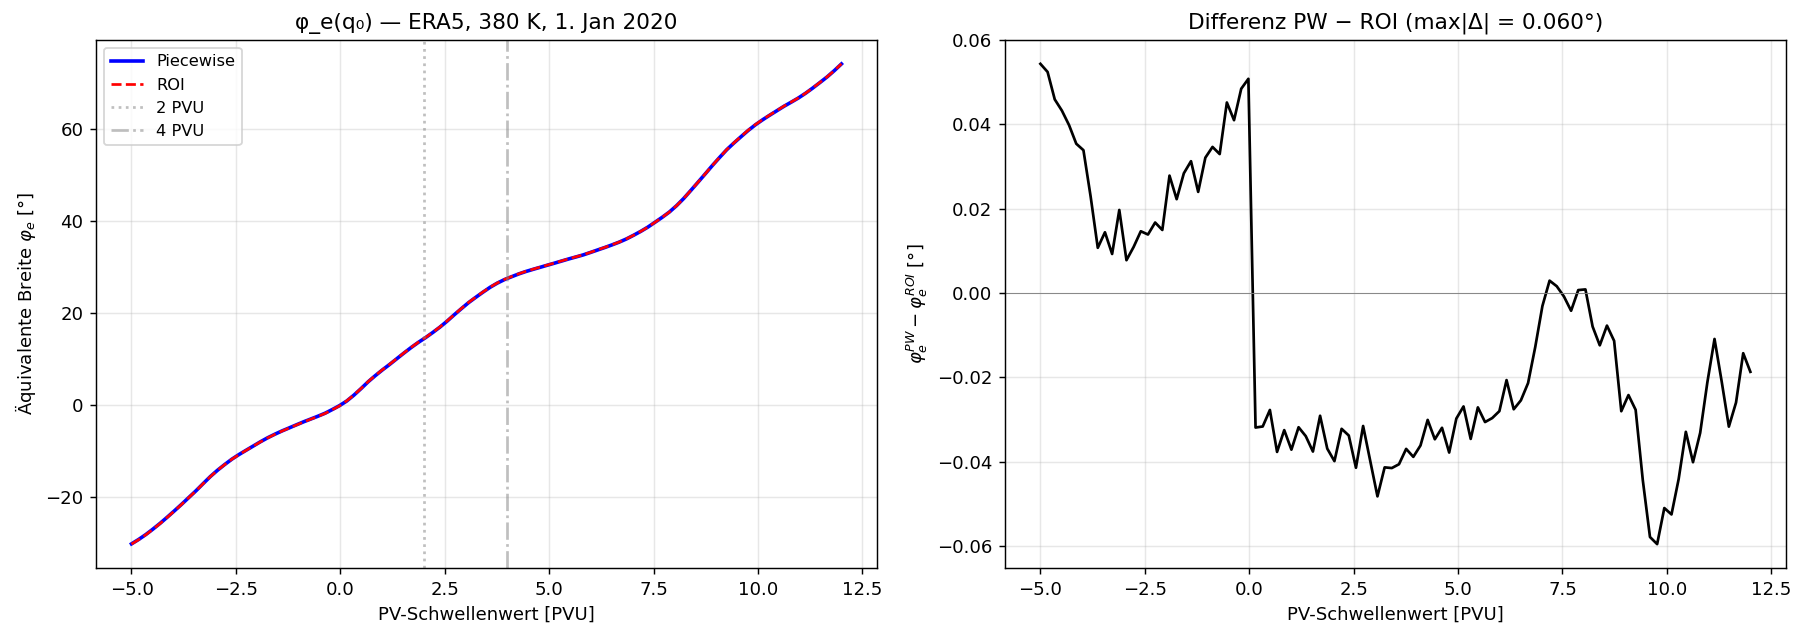

In [48]:
# --- Volles φ_e-Profil ---
thresh_full = np.linspace(-5, 12, 100)
res_pw_full = equivalent_latitude_piecewise(pv, lat, lon, pv_thresholds=thresh_full)
res_roi_full = equivalent_latitude_roi(pv, lat, lon, pv_thresholds=thresh_full)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# φ_e Profil
ax = axes[0]
ax.plot(thresh_full, res_pw_full['eqlat'], 'b-', lw=2, label='Piecewise')
ax.plot(thresh_full, res_roi_full['eqlat'], 'r--', lw=1.5, label='ROI')
ax.axvline(2.0, color='gray', ls=':', alpha=0.5, label='2 PVU')
ax.axvline(4.0, color='gray', ls='-.', alpha=0.5, label='4 PVU')
ax.set_xlabel('PV-Schwellenwert [PVU]')
ax.set_ylabel('Äquivalente Breite $\\varphi_e$ [°]')
ax.set_title('φ_e(q₀) — ERA5, 380 K, 1. Jan 2020')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Differenz
ax = axes[1]
diff_full = res_pw_full['eqlat'] - res_roi_full['eqlat']
ax.plot(thresh_full, diff_full, 'k-', lw=1.5)
ax.axhline(0, color='gray', lw=0.5)
ax.set_xlabel('PV-Schwellenwert [PVU]')
ax.set_ylabel('$\\varphi_e^{PW} - \\varphi_e^{ROI}$ [°]')
ax.set_title(f'Differenz PW − ROI (max|Δ| = {np.max(np.abs(diff_full)):.3f}°)')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


2.5°-Gitter: 72×144 Punkte
φ_e (PW):  14.08°
φ_e (ROI): 14.36°
Differenz: -0.278°


/opt/miniconda3/envs/earth-analytics-python/lib/python3.11/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


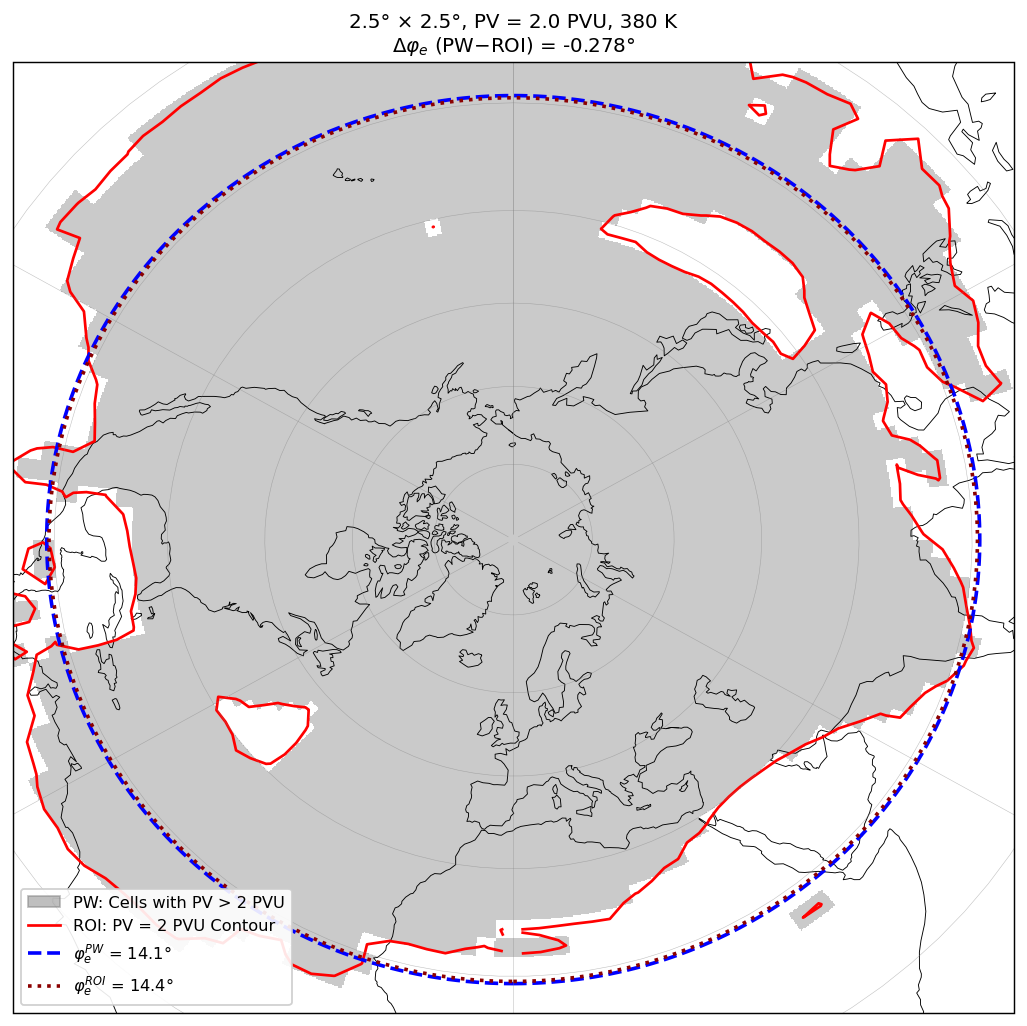

In [50]:
# --- Figure 1 (polzentriert) bei 2.5° Auflösung ---
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.patches as mpatches

data = np.load('../data_pv380k.npz')
pv_orig = data['pv']
lat_orig = data['lat']
lon_orig = data['lon']
if lat_orig[0] > lat_orig[-1]:
    lat_orig = lat_orig[::-1]
    pv_orig = pv_orig[::-1, :]

def coarsen_grid(pv, lat, lon, factor):
    nlat_new = len(lat) // factor
    nlon_new = len(lon) // factor
    pv_trim = pv[:nlat_new*factor, :nlon_new*factor]
    pv_c = pv_trim.reshape(nlat_new, factor, nlon_new, factor).mean(axis=(1, 3))
    lat_c = lat[:nlat_new*factor].reshape(nlat_new, factor).mean(axis=1)
    lon_c = lon[:nlon_new*factor].reshape(nlon_new, factor).mean(axis=1)
    return pv_c, lat_c, lon_c

pv_25, lat_25, lon_25 = coarsen_grid(pv_orig, lat_orig, lon_orig, factor=10)
print(f"2.5°-Gitter: {len(lat_25)}×{len(lon_25)} Punkte")

pv_threshold = 2.0  # PVU

res_pw_25  = equivalent_latitude_piecewise(pv_25, lat_25, lon_25, pv_thresholds=np.array([pv_threshold]))
res_roi_25 = equivalent_latitude_roi(pv_25, lat_25, lon_25, pv_thresholds=np.array([pv_threshold]))
eqlat_pw_25  = res_pw_25['eqlat'][0]
eqlat_roi_25 = res_roi_25['eqlat'][0]
print(f"φ_e (PW):  {eqlat_pw_25:.2f}°")
print(f"φ_e (ROI): {eqlat_roi_25:.2f}°")
print(f"Differenz: {eqlat_pw_25 - eqlat_roi_25:.3f}°")

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.NorthPolarStereo())
ax.set_extent([-180, 180, 10, 90], ccrs.PlateCarree())

# PW-Fläche (grau) — extent auf Zellkanten (0°–360°, -90°–90°)
pw_mask = np.where(pv_25 > pv_threshold, 0.5, np.nan)
ax.imshow(pw_mask, origin='lower',
          extent=[0, 360, -90, 90],
          transform=ccrs.PlateCarree(),
          interpolation='nearest',
          cmap='Greys', vmin=0, vmax=1,
          alpha=0.5, aspect='auto')

# ROI-Kontur (rot)
ax.contour(lon_25, lat_25, pv_25, levels=[pv_threshold],
           transform=ccrs.PlateCarree(),
           colors='red', linewidths=1.5)

# φ_e-Kreise
circle_lon = np.linspace(0, 360, 361)
ax.plot(circle_lon, np.full_like(circle_lon, eqlat_pw_25),
        transform=ccrs.PlateCarree(),
        color='blue', linewidth=2, linestyle='--')
ax.plot(circle_lon, np.full_like(circle_lon, eqlat_roi_25),
        transform=ccrs.PlateCarree(),
        color='darkred', linewidth=2, linestyle=':')

ax.add_feature(cfeature.COASTLINE, linewidth=0.5, color='k')
ax.gridlines(draw_labels=False, linewidth=0.3, color='gray', alpha=0.5,
             ylocs=np.arange(0, 90, 15))

gray_patch = mpatches.Patch(color='gray', alpha=0.5, label='PW: Cells with PV > 2 PVU')
red_line  = plt.Line2D([0], [0], color='red', lw=1.5, label='ROI: PV = 2 PVU Contour')
blue_line = plt.Line2D([0], [0], color='blue', lw=2, ls='--', label=f'$\\varphi_e^{{PW}}$ = {eqlat_pw_25:.1f}°')
dred_line = plt.Line2D([0], [0], color='darkred', lw=2, ls=':', label=f'$\\varphi_e^{{ROI}}$ = {eqlat_roi_25:.1f}°')
ax.legend(handles=[gray_patch, red_line, blue_line, dred_line],
          loc='lower left', fontsize=9, framealpha=0.9)

ax.set_title(f'2.5° × 2.5°, PV = {pv_threshold} PVU, 380 K\n'
             f'$\\Delta\\varphi_e$ (PW−ROI) = {eqlat_pw_25 - eqlat_roi_25:.3f}°', fontsize=11)

plt.tight_layout()
plt.show()
